<a href="https://colab.research.google.com/github/chaitanysaraswat/Advanced-Analytics-Using-Statistics/blob/main/lecture13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `PML (practical machine learning)`

- supervised learning model:- certain output column present or columns where u put labels.
- unsupervised learning model:-don't have output column or labels.
- reinforcement model:- not talk abt much in industry

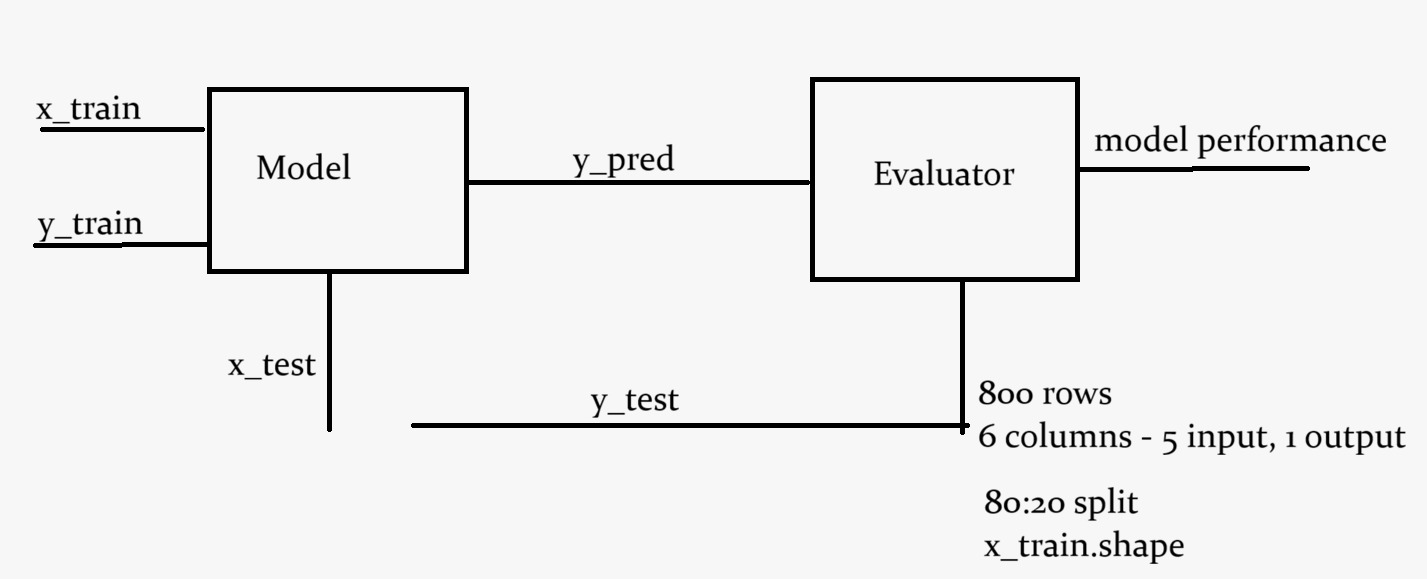

- x_train 640rows 5 input
- y_train 640rows 1 column(output)
- x_test 160 rows to test model  and
-  y pred created (output created through model)
- y_test:160 y_test known result will be checked with y_pred output of model

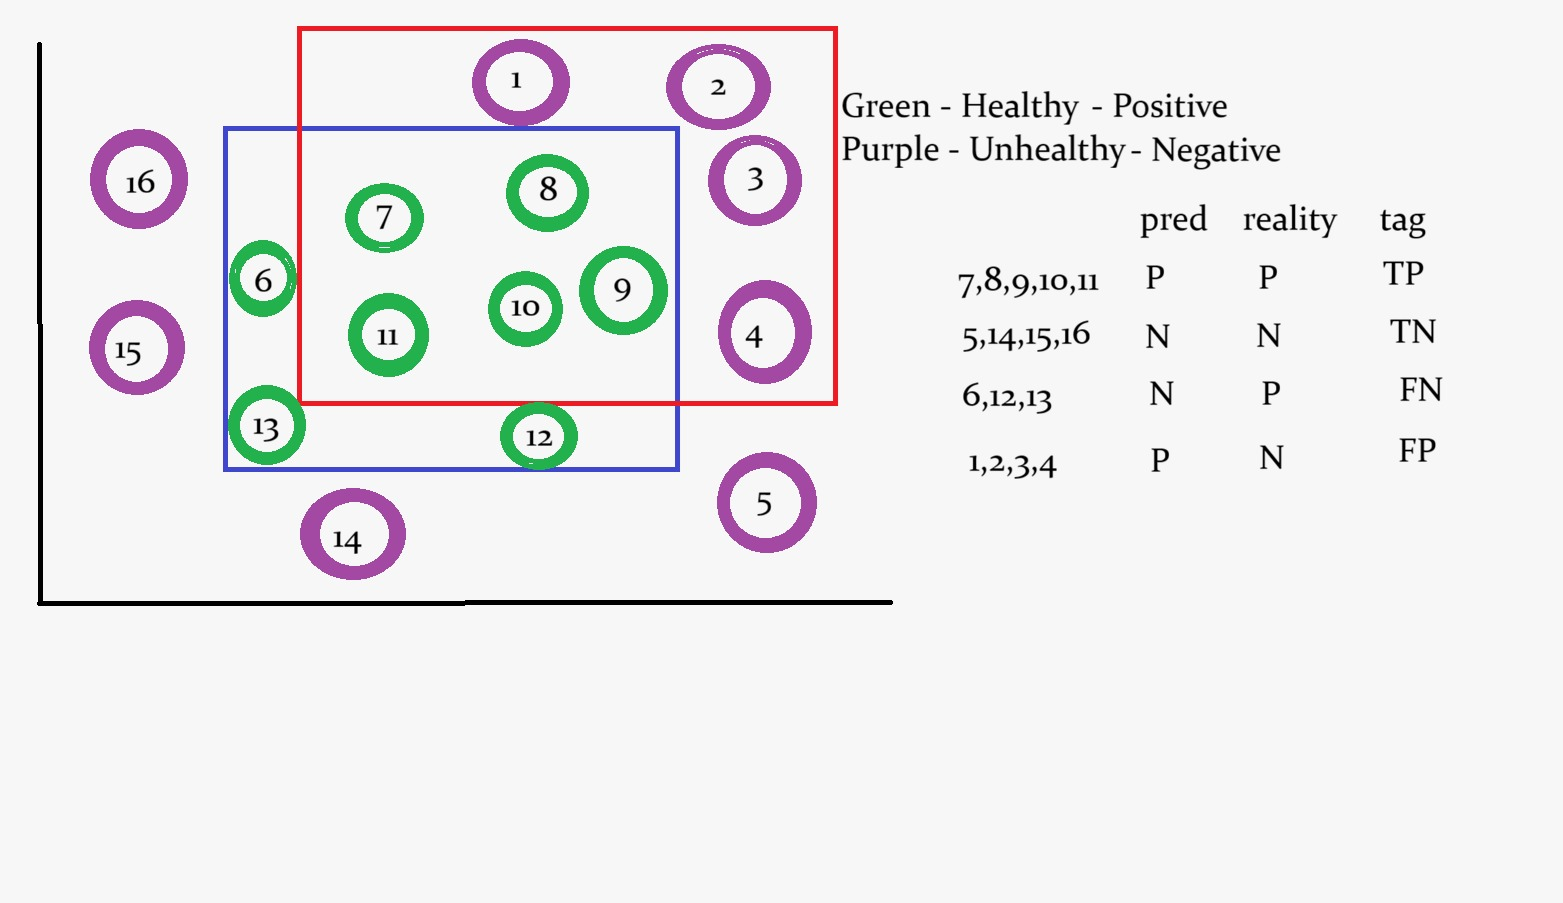

FOR  AN EXTREMELY COMPLEX MODEL:
- the bias will really low but the variance is going to be high this is called OVERFITTING

- UNDERFITTING:-Bias high , Variance is low

---
error of the model =bias^2+induced error+variance

std^2 = variance

std^2=(xbar- mu)/n

graph:

- underfitting: keyword "model is too simple"
- fails to capture pattern
- Bias high , Variance is low


|\ Aspect | Underfitting | Overfitting |
| :--- | :--- | :--- |
| **Bias** | High | Low |
| &nbsp; | | |
| **Variance** | Low | High |
| &nbsp; | | |
| **Training Error** | High | Very Low |
| &nbsp; | | |
| **Test Error** | High | High |
| &nbsp; | | |
| **Complexity** | Low | High |


# `REGRESSION`
- there are 8 regression model

- and 3 are most important

simple linear regression:

*   response is single continuous there is only one predictor which is  continuous

multiple linear regression



tangent : slope of the line  also defined as tan  is angle line makes with

positive x axis

first quadrant positive angle(0,90)

second quadrant negative angle(greater than 90)

c is line at which line intersect x at ex(0,4)
m is the angle  take tan0(p/b) of that angle
t1 is positivr and t2 is is negative of obtuse angle

----

REGRESSION NULL HYPOTHESIS

y=mx+c

H0(m) :m=0
x doesn't influence y

H0(C):C=0
C DOEN'T INFLUENCE Y


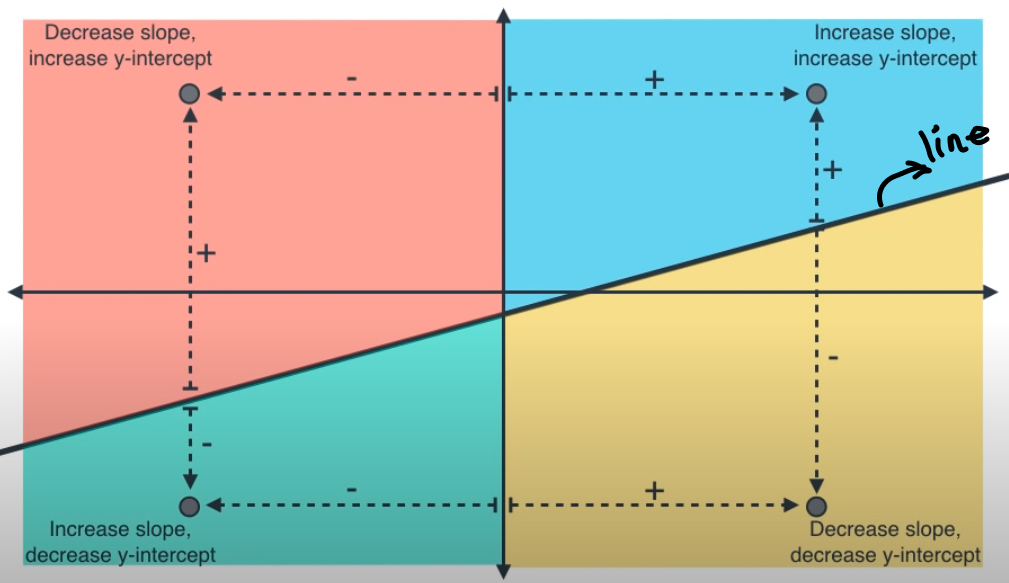


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
df = pd.read_excel('/content/drive/MyDrive/My pitch/CDAC_DataBook.xlsx', sheet_name='faithful')

In [ ]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [ ]:
scipy.stats.pearsonr(df.eruptions,df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

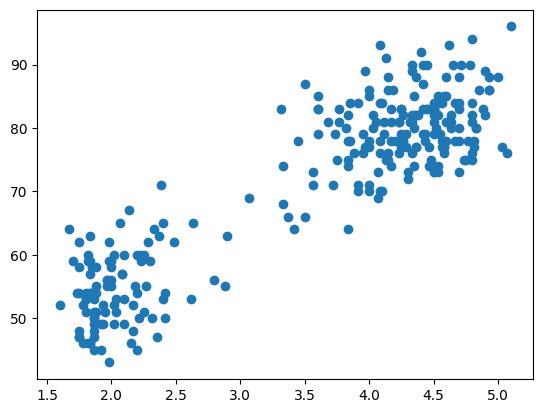

In [ ]:
plt.scatter(df.eruptions,df.waiting)

In [ ]:
# \(y\) is the dependent response.\(x\) is the independent predictor.\(m\) is the slope.\(b\) is the y-intercept.

x_train,x_test,y_train,y_test=train_test_split(df.waiting,df.eruptions,test_size=0.3)
print(len(x_train))
print(len(x_test))

190
82


In [ ]:
y_train.head()

,eruptions
71,1.967
267,4.117
154,3.567
196,3.500
156,4.500


In [ ]:
x_train.head()

,waiting
71,56
267,81
154,71
196,87
156,81


In [ ]:
df.shape

(272, 2)

In [ ]:
272*0.7

190.39999999999998

In [ ]:
x_train.shape

(190,)

In [ ]:
# train and test data split
x_train,x_test,y_train,y_test=train_test_split(df.waiting,df.eruptions,test_size=0.3,random_state=20)
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [ ]:
# add constant term

x_train=sm.add_constant(x_train,prepend=False)
x_test=sm.add_constant(x_test,prepend=False)
x_train.head()

,waiting,const
182,83,1.0
248,67,1.0
50,75,1.0
209,83,1.0
200,60,1.0


most  imp
- waiting coef m
- const -2.08 c
- eruptions=0.0782*waiting-2.08

- y=mx +c

- r squared(coefficient of determination)

it signifies percentage of variation in data explained by the model


null hypothesis

p value
what  is p value  we have to do
wha tconclusion drawn

In [ ]:
#prepare model
mod1=sm.OLS(y_train,x_train).fit()
print(mod1.summary())
# R-squared:                       0.804 80% variations is explained by model it is used testing using x_train dataset after making model
# ==============================================================================
#                  coef        std err          t                  P>|t|                 [0.025      0.975]
# ------------------------------------------------------------------------------
# waiting        0.0782(m)      0.003     27.768coef/stderr      0.000(norm.ppf(t))       0.073q1       0.084q3
# const         -2.0814(c)      0.203    -10.273coef/stderr      0.000(norm.ppf(t))      -2.481      -1.682
# ==============================================================================

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        09:09:18   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

y(output,response,dependent)= mx(predictor,independent)+c

in train test split command  first is  x(waiting) y(eruptions)

F= b/w/within  =  explained/unexpalined

In [ ]:
mydata = pd.DataFrame([[80,1],[90,1],[100,1]], columns = x_train.columns)
mypreds = mod1.predict(mydata)
mypreds

,0
0,4.176827
1,4.959109
2,5.741392


In [ ]:
y_preds=mod1.predict(x_train)
print(y_preds.head(),end='\n\n')

print(y_train.head())

182    4.411512
248    3.159859
50     3.785686
209    4.411512
200    2.612262
dtype: float64

182    4.250
248    2.133
50     4.800
209    4.500
200    2.100
Name: eruptions, dtype: float64


(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

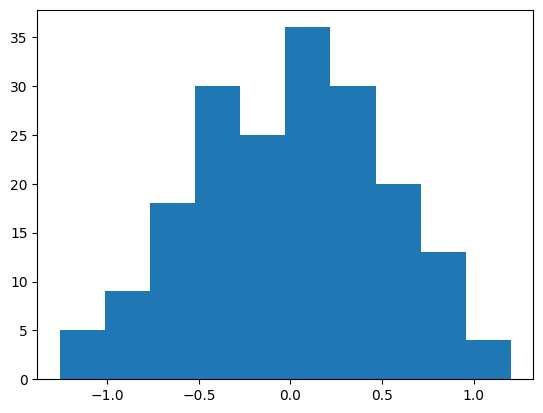

In [ ]:
residual=y_train-y_preds
plt.hist(residual)

In [ ]:
SSE=sum(residual**2) # sum of square error is the explained variation b/w y_train and y_pred when we put known data
# it is called unexplained error

In [ ]:
sst= sum((y_train-np.mean(y_train))**2)
# SST stands for sum square of total variation
# sst total error

In [ ]:
SSR  =  sst - SSE
SSR
# sum square of regression or expalined variation

200.9543260813924

In [ ]:
SSR/sst     # fraction of total variation explained by the model  this ratio is the same as r2

0.803974495320098

In [ ]:
F=((SSR)/(1))/(SSE/188)
F
# NUMBER OF VALUES=190
# TOTAL DF=189
# DOF OF REGRESSION=2(m+c)-1=1
# DOF for error or residual=189-1=188

771.0588750529828

coefficient of waiting 0.0782 is the increase in the response were the predictor waiting is increased by one unit keeping all factor constant

e1=0.07828*w-2.08
e2=0.0782*(w+1)-2.08
e2-e1=0.